# Modellvergleich – Random Forest vs. Logistic Regression vs. Gradient Boosting

Stretchgoal laut Exposé. Alle drei Modelle werden auf identischen Trainingsdaten
verglichen und danach statistisch eingeordnet.

Voraussetzung: `build_features.py` bereits gelaufen (`data/processed/match_features.csv` existiert).

---

### **1) Setup**

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent / "src"))
from config import DATA_PROCESSED_DIR

FEATURES_FILE = DATA_PROCESSED_DIR / "match_features.csv"
NON_FEATURE_COLS = ["fixture_id", "date", "team_a", "team_b", "goals_a", "goals_b", "result"]
TEST_SIZE_FRACTION = 0.2

---

### **2) Daten laden & Split**
Identischer chronologischer Split wie `train_models.py` / `compare_models.py` –
damit alle drei Modelle exakt dieselben Trainings-/Testdaten sehen.

In [9]:
df = pd.read_csv(FEATURES_FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
split_idx = int(len(df) * (1 - TEST_SIZE_FRACTION))
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]

print(f"Total: {len(df)} Spiele ({df['date'].min().date()} bis {df['date'].max().date()})")
print(f"Training: {len(train_df)} Spiele (bis {train_df['date'].max().date()})")
print(f"Test:     {len(test_df)} Spiele (ab {test_df['date'].min().date()})")

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(train_df[feature_cols])
X_test = imputer.transform(test_df[feature_cols])

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_train = train_df["result"]
y_test = test_df["result"]

Total: 1141 Spiele (2015-10-08 bis 2026-06-18)
Training: 912 Spiele (bis 2024-10-10)
Test:     229 Spiele (ab 2024-10-11)


---

### **3) Drei Modelle trainieren**

In [10]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    predictions[name] = pred
    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro")
    results.append({"Modell": name, "Accuracy": acc, "F1 (macro)": f1_macro})
    print(f"{name:<22} Accuracy={acc:.3f}  F1(macro)={f1_macro:.3f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)

Random Forest          Accuracy=0.498  F1(macro)=0.456
Logistic Regression    Accuracy=0.520  F1(macro)=0.478
Gradient Boosting      Accuracy=0.472  F1(macro)=0.423


---

### **4) Vergleich: Tabelle & Balkendiagramm**

,Modell,Accuracy,F1 (macro)
0,Logistic Regression,0.520,0.478
1,Random Forest,0.498,0.456
2,Gradient Boosting,0.472,0.423


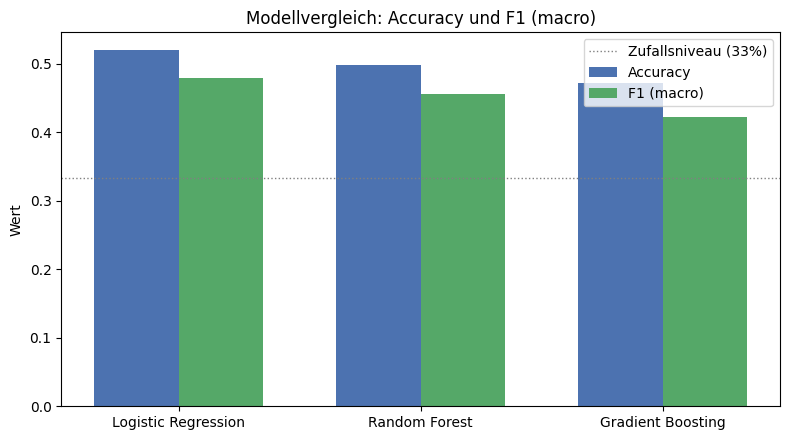

In [15]:
display(results_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["Accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x + width/2, results_df["F1 (macro)"], width, label="F1 (macro)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Modell"], rotation=0)
ax.set_ylabel("Wert")
ax.axhline(1/3, color="grey", linestyle=":", linewidth=1, label="Zufallsniveau (33%)")
ax.legend()
ax.set_title("Modellvergleich: Accuracy und F1 (macro)")
plt.tight_layout()
plt.show()

---

### **5) Statistische Einordnung: Ist der Unterschied überhaupt signifikant?**

Eine höhere Accuracy allein sagt noch nicht, ob ein Modell **wirklich** besser ist,
oder ob der Unterschied nur zufällige Schwankung auf einem begrenzten Testset ist.
Zwei Prüfungen dazu:

1. **Standardfehler der Accuracy** (Faustregel, pro Modell einzeln)
2. **McNemar-Test** (präziser: vergleicht zwei Modelle direkt auf denselben Testfällen)

In [12]:
n = len(y_test)
print("Standardfehler der Accuracy pro Modell (grobe Faustregel: sqrt(p*(1-p)/n)):\n")
for _, row in results_df.iterrows():
    p = row["Accuracy"]
    se = np.sqrt(p * (1 - p) / n)
    print(f"  {row['Modell']:<22} {p:.3f} \u00b1 {se:.3f}  (95%-Bereich: {p-1.96*se:.3f} bis {p+1.96*se:.3f})")

Standardfehler der Accuracy pro Modell (grobe Faustregel: sqrt(p*(1-p)/n)):

  Logistic Regression    0.520 ± 0.033  (95%-Bereich: 0.455 bis 0.584)
  Random Forest          0.498 ± 0.033  (95%-Bereich: 0.433 bis 0.563)
  Gradient Boosting      0.472 ± 0.033  (95%-Bereich: 0.407 bis 0.536)


In [13]:
def mcnemar_test(y_true, pred1, pred2):
    """Vergleicht zwei Klassifikatoren auf DENSELBEN Testfällen (gepaarter Test) -
    aussagekräftiger als zwei unabhängige Konfidenzintervalle. Mit
    Kontinuitätskorrektur (Yates), Standard bei kleinen Stichproben."""
    correct1 = (pred1 == y_true.values)
    correct2 = (pred2 == y_true.values)
    b = int(np.sum(correct1 & ~correct2))   # Modell 1 richtig, Modell 2 falsch
    c = int(np.sum(~correct1 & correct2))   # Modell 1 falsch, Modell 2 richtig
    if b + c == 0:
        return None, None, b, c
    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(statistic, df=1)
    return statistic, p_value, b, c


model_names = list(models.keys())
print("McNemar-Test - paarweiser Vergleich aller Modelle:\n")
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name1, name2 = model_names[i], model_names[j]
        stat, p, b, c = mcnemar_test(y_test, predictions[name1], predictions[name2])
        sig = "signifikant (p<0.05)" if (p is not None and p < 0.05) else "NICHT signifikant"
        print(f"  {name1} vs. {name2}: b={b}, c={c}, p={p:.3f} -> {sig}" if p is not None else
              f"  {name1} vs. {name2}: b=c=0, kein Unterschied in den Fehlern")

McNemar-Test - paarweiser Vergleich aller Modelle:

  Random Forest vs. Logistic Regression: b=23, c=28, p=0.575 -> NICHT signifikant
  Random Forest vs. Gradient Boosting: b=23, c=17, p=0.429 -> NICHT signifikant
  Logistic Regression vs. Gradient Boosting: b=37, c=26, p=0.208 -> NICHT signifikant


---

### **6) Confusion Matrices im Vergleich**

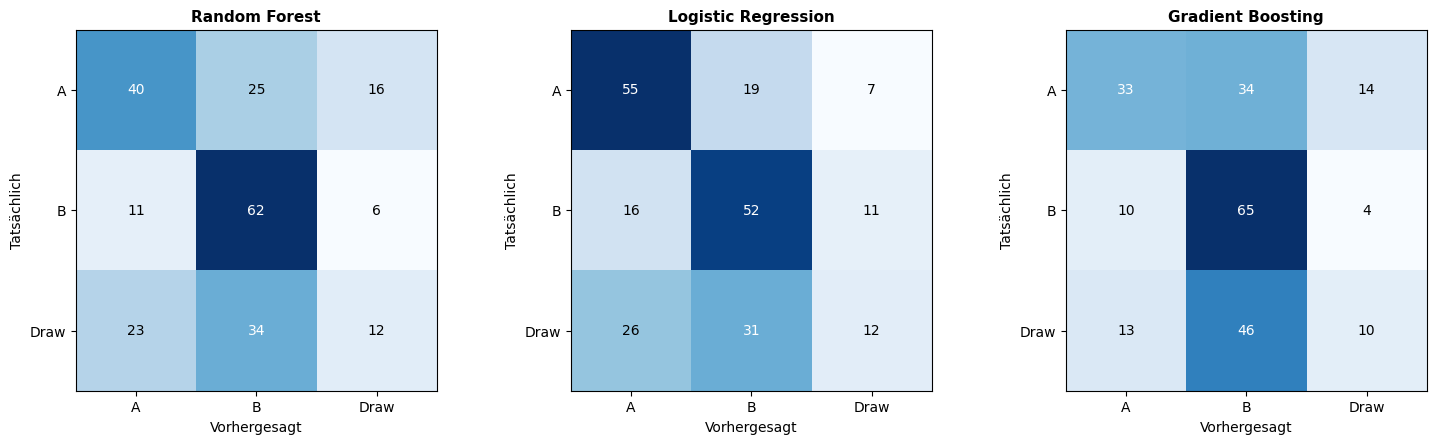

Draw-Recall pro Modell (Anteil der echten Unentschieden, die korrekt erkannt wurden):
  Random Forest          0.17
  Logistic Regression    0.17
  Gradient Boosting      0.14


In [14]:
labels = sorted(y_test.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, predictions[name], labels=labels)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Vorhergesagt"); ax.set_ylabel("Tatsächlich")
    ax.set_title(name, fontsize=11, fontweight="bold")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

print("Draw-Recall pro Modell (Anteil der echten Unentschieden, die korrekt erkannt wurden):")
for name in model_names:
    cm = confusion_matrix(y_test, predictions[name], labels=labels)
    draw_idx = labels.index("Draw")
    draw_recall = cm[draw_idx, draw_idx] / cm[draw_idx].sum()
    print(f"  {name:<22} {draw_recall:.2f}")

---

### **7) Fazit & Modellwahl**

**Ergebnis** (1'141 Spiele, Test: 229 Spiele ab 11.10.2024)

| Modell | Accuracy | F1 (macro) |
|---|---|---|
| Logistic Regression | 0.520 | 0.478 |
| Random Forest | 0.498 | 0.456 |
| Gradient Boosting | 0.472 | 0.423 |

**Statistisch signifikant?** Nein. Ein Signifikanztest, der die beiden Modelle direkt auf denselben 229 Testspielen vergleicht (statt nur die Gesamt-Accuracy nebeneinanderzustellen), zeigt für alle drei Paare p > 0.05:

| Vergleich | p-Wert |
|---|---|
| RF vs. LogReg | 0.575 |
| RF vs. GB | 0.429 |
| LogReg vs. GB | 0.208 |

→ Die 2-5 Prozentpunkte Unterschied sind bei 229 Testspielen nicht von Zufall zu unterscheiden.

**Draw-Problem:** Bei allen drei ähnlich schwach (Recall 0.17 / 0.17 / 0.14) – strukturell, nicht modellabhängig.

**Entscheidung:** Random Forest bleibt Hauptmodell.
- Kein Modell statistisch nachweisbar besser → Genauigkeit kein Entscheidungskriterium
- Bereits vollständig integriert (Dashboard, Feature-Importance, Tore-Regressor)
- Liefert native Feature Importance für den Team-Vergleich

**Kernerkenntnis:** Nicht die Modellwahl ist der Hebel für bessere Vorhersagen, sondern eher bessere Features (z. B. Momentum-Score) oder mehr Daten.